# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
### LOADING THE DATASET
# Dataset contain 60K colored images of dimension 32x32x3

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


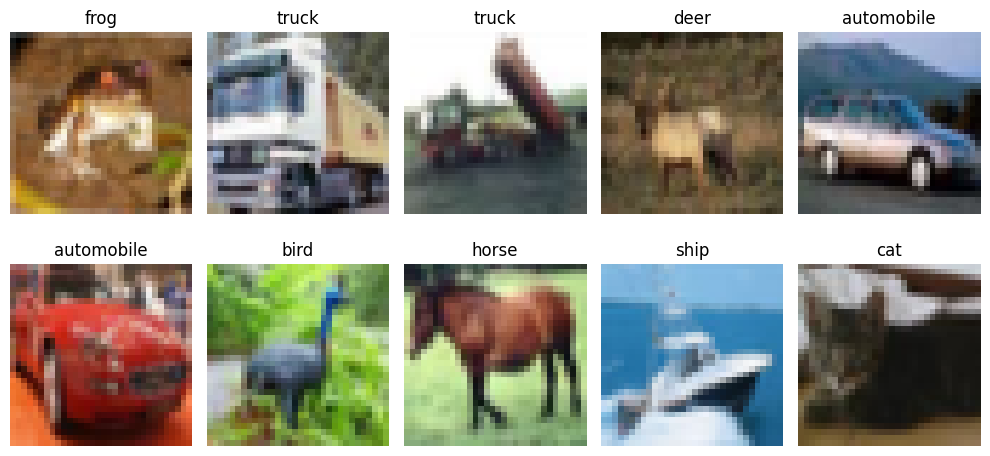

In [4]:
### HOW A SAMPLE IMAGE LOOKS LIKE

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [5]:
### PREPROCESSING --> NORMALIZATION


x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

In [6]:
### ANN MODEL
### It treats images as flat vectors


ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.2632 - loss: 2.0089 - val_accuracy: 0.3396 - val_loss: 1.8551
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3110 - loss: 1.8788 - val_accuracy: 0.3552 - val_loss: 1.7890
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3348 - loss: 1.8200 - val_accuracy: 0.3614 - val_loss: 1.7598
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3525 - loss: 1.7805 - val_accuracy: 0.3684 - val_loss: 1.7619
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3631 - loss: 1.7543 - val_accuracy: 0.3846 - val_loss: 1.7141
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3693 - loss: 1.7321 - val_accuracy: 0.4038 - val_loss: 1.6937
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3784 - loss: 1.7122 - val_accuracy: 0.4152 - val_loss: 1.6549
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3846 - loss: 1.6994 - val_accuracy: 0.

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4417 - loss: 1.5869
ANN Test Accuracy: 0.4417000114917755


In [8]:
### CNN MODEL
### Usually better than ANN



cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.4712 - loss: 1.4800 - val_accuracy: 0.5518 - val_loss: 1.2692
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6054 - loss: 1.1296 - val_accuracy: 0.5904 - val_loss: 1.2101
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6680 - loss: 0.9511 - val_accuracy: 0.6564 - val_loss: 0.9729
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7132 - loss: 0.8235 - val_accuracy: 0.7206 - val_loss: 0.8112
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7464 - loss: 0.7290 - val_accuracy: 0.7158 - val_loss: 0.8100
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7719 - loss: 0.6424 - val_accuracy: 0.7006 - val_loss: 0.8660
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7949 - loss: 0.5757 - val_accuracy: 0.7124 - val_loss: 0.8475
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8154 - loss: 0.5223 - val_accuracy: 

In [9]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7177 - loss: 1.2862
CNN Test Accuracy: 0.7177000045776367


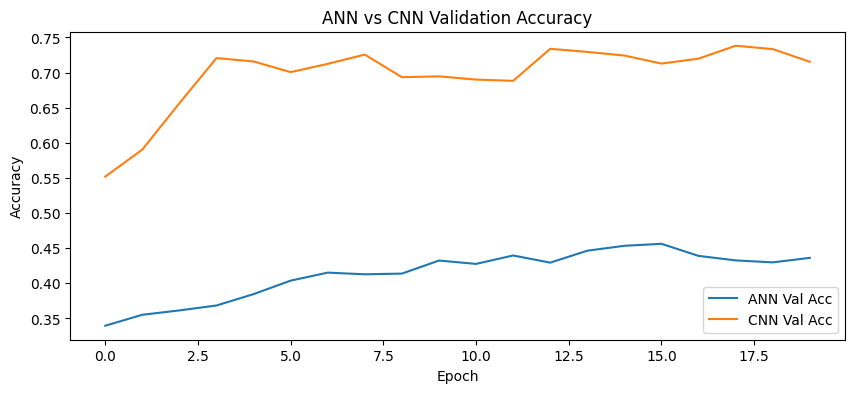

In [10]:
### COMPARING LEARNING CURVES

plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.3808 - loss: 1.6941 - val_accuracy: 0.4796 - val_loss: 1.4318
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.4794 - loss: 1.4489 - val_accuracy: 0.5542 - val_loss: 1.2502
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.5195 - loss: 1.3553 - val_accuracy: 0.5832 - val_loss: 1.1630
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5425 - loss: 1.2946 - val_accuracy: 0.6106 - val_loss: 1.1039
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5572 - loss: 1.2522 - val_accuracy: 0.6146 - val_loss: 1.1008
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5698 - loss: 1.2185 - val_accuracy: 0.6286 - val_loss: 1.0552
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5800 - loss: 1.1899 - val_accuracy: 0.6450 - val_loss: 0.9998
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5871 - loss: 1

In [12]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Augmented CNN"],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)[1]
    ]
})

comparison

,Model,Test Accuracy
0,ANN,0.4417
1,CNN,0.7177
2,Augmented CNN,0.6491


In [13]:
### IMPROVING THE ANN MODEL


ann_model = models.Sequential([

    # Input layer
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    # Hidden layer 1
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    # Hidden layer 2
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    # Hidden layer 3
    layers.Dense(64, activation='relu'),

    # Output layer
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.2218 - loss: 2.0763 - val_accuracy: 0.2808 - val_loss: 1.9097
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2877 - loss: 1.9231 - val_accuracy: 0.3272 - val_loss: 1.8613
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3056 - loss: 1.8761 - val_accuracy: 0.3390 - val_loss: 1.8170
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3178 - loss: 1.8466 - val_accuracy: 0.3518 - val_loss: 1.7966
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3279 - loss: 1.8253 - val_accuracy: 0.3538 - val_loss: 1.7821
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3301 - loss: 1.8192 - val_accuracy: 0.3766 - val_loss: 1.7535
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3407 - loss: 1.7964 - val_accuracy: 0.3602 - val_loss: 1.7749
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3472 - loss: 1.7891 - val_accuracy: 0

In [14]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4060 - loss: 1.7080
ANN Test Accuracy: 0.4059999883174896


In [15]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Augmented CNN"],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)[1]
    ]
})

comparison

,Model,Test Accuracy
0,ANN,0.4060
1,CNN,0.7177
2,Augmented CNN,0.6491


In [16]:
### UPDATED CNN MODEL
### CHANGING CNN Filters --> 32--> 64 --> 128



cnn_model = models.Sequential([

    # First convolution block
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    # Second convolution block
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Third convolution block
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten layer
    layers.Flatten(),

    # Dense layer
    layers.Dense(128, activation='relu'),

    # Dropout
    layers.Dropout(0.4),

    # Output layer
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.3669 - loss: 1.7028 - val_accuracy: 0.4996 - val_loss: 1.3740
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5164 - loss: 1.3405 - val_accuracy: 0.5822 - val_loss: 1.1790
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5816 - loss: 1.1839 - val_accuracy: 0.6178 - val_loss: 1.0683
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6161 - loss: 1.0864 - val_accuracy: 0.6442 - val_loss: 1.0168
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6525 - loss: 0.9924 - val_accuracy: 0.6574 - val_loss: 0.9830
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6751 - loss: 0.9251 - val_accuracy: 0.6852 - val_loss: 0.9089
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6975 - loss: 0.8646 - val_accuracy: 0.7016 - val_loss: 0.8549
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7162 - loss: 0.8185 - val_accuracy: 0.

In [17]:
deep_cnn_test_loss, deep_cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)

print("Deep CNN Test Accuracy:", deep_cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7022 - loss: 0.8651
Deep CNN Test Accuracy: 0.7021999955177307


In [18]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop training if validation loss stops improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train CNN with EarlyStopping
early_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7614 - loss: 0.6858 - val_accuracy: 0.7290 - val_loss: 0.8061
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7716 - loss: 0.6553 - val_accuracy: 0.7368 - val_loss: 0.7851
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7826 - loss: 0.6169 - val_accuracy: 0.7150 - val_loss: 0.8590
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7905 - loss: 0.5923 - val_accuracy: 0.7136 - val_loss: 0.8739
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7989 - loss: 0.5682 - val_accuracy: 0.7302 - val_loss: 0.8404


In [19]:
early_test_loss, early_test_acc = cnn_model.evaluate(x_test_norm, y_test)

print("CNN with EarlyStopping Accuracy:", early_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7221 - loss: 0.8183
CNN with EarlyStopping Accuracy: 0.722100019454956


In [20]:
comparison = pd.DataFrame({
    "Model": [
        "ANN",
        "CNN",
        "Augmented CNN",
        "CNN (32→64→128)",
        "CNN + EarlyStopping"
    ],

    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)[1],
        deep_cnn_test_acc,
        early_test_acc
    ]
})

comparison

,Model,Test Accuracy
0,ANN,0.4060
1,CNN,0.7177
2,Augmented CNN,0.6491
3,CNN (32→64→128),0.7022
4,CNN + EarlyStopping,0.7221


In [ ]:
# DONE